<a href="https://colab.research.google.com/github/zvythrox67/clinical-fairness-audit/blob/main/Rare_Disease_Diagnostic_Support.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fairlearn xgboost shap aif360 -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference, selection_rate

from aif360.algorithms.preprocessing import Reweighing
from aif360.datasets import StandardDataset

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 4.5 MB/s eta 0:00:00


pip install 'aif360[inFairness]'


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if 'lending' in f.lower() or 'accepted' in f.lower() or 'loan' in f.lower():
            print(os.path.join(root, f))

In [ ]:
#Load and Clean LendingClub Data
from google.colab import drive
drive.mount('/content/drive')

import os

FILE_PATH = '/content/drive/MyDrive/accepted_2007_to_2018Q4.csv.gz'

usecols = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'loan_status', 'zip_code'
]

df = pd.read_csv(FILE_PATH, usecols=usecols, low_memory=False, compression='gzip')
print(f"Initial shape: {df.shape}")

df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
print(f"After filtering: {df.shape}")

df['target'] = (df['loan_status'] == 'Charged Off').astype(int)
df = df.drop(columns=['loan_status'])
df = df.dropna(subset=['target', 'zip_code'])

num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"Final shape: {df.shape}")
print(df['target'].value_counts(normalize=True))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Initial shape: (2260701, 22)
After filtering: (1345310, 22)
Final shape: (1345309, 22)
target
0    0.800374
1    0.199626
Name: proportion, dtype: float64


In [ ]:
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)
df['monthly_payment_pct'] = df['installment'] / ((df['annual_inc'] / 12) + 1)
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade_num'] = df['grade'].map(grade_map)
df['zip3'] = df['zip_code'].astype(str).str[:3]

df['income_group'] = pd.qcut(df['annual_inc'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
sensitive_feature = 'income_group'
unprivileged_group = 'Q1'

feature_cols = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
    'delinq_2yrs', 'fico_range_low', 'inq_last_6mths', 'open_acc',
    'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'loan_to_income', 'monthly_payment_pct', 'grade_num'
]

X = df[feature_cols].copy()
y = df['target'].copy()
sensitive = df[sensitive_feature].copy()

X_train, X_test, y_train, y_test, sens_train, sens_test = train_test_split(
    X, y, sensitive, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(1076247, 16) (269062, 16)


scale_pos_weight = 4.0094
Accuracy: 0.6388
ROC-AUC: 0.7116
              precision    recall  f1-score   support

           0       0.89      0.63      0.74    215350
           1       0.31      0.68      0.43     53712

    accuracy                           0.64    269062
   macro avg       0.60      0.65      0.58    269062
weighted avg       0.77      0.64      0.67    269062



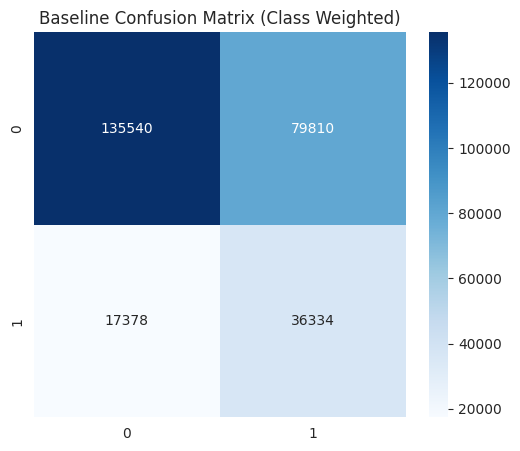

In [ ]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale:.4f}")

model = xgb.XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Baseline Confusion Matrix (Class Weighted)')
plt.show()

In [ ]:
metrics = {
    'accuracy': accuracy_score,
    'selection_rate': selection_rate,
    'false_positive_rate': lambda yt, yp: confusion_matrix(yt, yp).ravel()[1] / (confusion_matrix(yt, yp).ravel()[1] + confusion_matrix(yt, yp).ravel()[0]),
    'true_positive_rate': lambda yt, yp: confusion_matrix(yt, yp).ravel()[3] / (confusion_matrix(yt, yp).ravel()[3] + confusion_matrix(yt, yp).ravel()[2])
}

mf = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_pred, sensitive_features=sens_test)
print(mf.by_group)

dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=sens_test)
eo_diff = equalized_odds_difference(y_test, y_pred, sensitive_features=sens_test)
print(f"DP Diff: {dp_diff:.4f}")
print(f"EO Diff: {eo_diff:.4f}")

              accuracy  selection_rate  false_positive_rate  \
income_group                                                  
Q1            0.774268        0.032095             0.017903   
Q2            0.789840        0.023959             0.013571   
Q3            0.810804        0.014847             0.007687   
Q4            0.838897        0.004655             0.002365   

              true_positive_rate  
income_group                      
Q1                      0.079537  
Q2                      0.062399  
Q3                      0.045052  
Q4                      0.016520  
DP Diff: 0.0274
EO Diff: 0.0630


In [ ]:
# Reweighing Mitigation (AIF360) + Class Weighting
scale = (y_train == 0).sum() / (y_train == 1).sum()

train_df = X_train.copy()
train_df['target'] = y_train.values.astype(int)
train_df['income_group'] = sens_train.astype(str).values

train_sds = StandardDataset(
    train_df,
    label_name='target',
    favorable_classes=[0],
    protected_attribute_names=['income_group'],
    privileged_classes=[['Q4']],
    categorical_features=[]
)

unprivileged_groups = [{'income_group': 'Q1'}]
privileged_groups   = [{'income_group': 'Q4'}]

reweighing = Reweighing(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)
reweighing.fit(train_sds)
train_sds_transf = reweighing.transform(train_sds)
sample_weights = train_sds_transf.instance_weights

model_rw = xgb.XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42, n_jobs=-1
)
model_rw.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_rw = model_rw.predict(X_test)
y_pred_proba_rw = model_rw.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_rw):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rw):.4f}")
print(classification_report(y_test, y_pred_rw))

mf_rw = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_pred_rw, sensitive_features=sens_test)
print(mf_rw.by_group)

dp_diff_rw = demographic_parity_difference(y_test, y_pred_rw, sensitive_features=sens_test)
eo_diff_rw = equalized_odds_difference(y_test, y_pred_rw, sensitive_features=sens_test)
print(f"DP Diff: {dp_diff_rw:.4f}")
print(f"EO Diff: {eo_diff_rw:.4f}")

/usr/local/lib/python3.13/dist-packages/aif360/algorithms/preprocessing/reweighing.py:66: RuntimeWarning: invalid value encountered in scalar divide
  self.w_p_fav = n_fav*n_p / (n*n_p_fav)
/usr/local/lib/python3.13/dist-packages/aif360/algorithms/preprocessing/reweighing.py:67: RuntimeWarning: invalid value encountered in scalar divide
  self.w_p_unfav = n_unfav*n_p / (n*n_p_unfav)
/usr/local/lib/python3.13/dist-packages/aif360/algorithms/preprocessing/reweighing.py:68: RuntimeWarning: invalid value encountered in scalar divide
  self.w_up_fav = n_fav*n_up / (n*n_up_fav)
/usr/local/lib/python3.13/dist-packages/aif360/algorithms/preprocessing/reweighing.py:69: RuntimeWarning: invalid value encountered in scalar divide
  self.w_up_unfav = n_unfav*n_up / (n*n_up_unfav)


Accuracy: 0.6388
ROC-AUC: 0.7116
              precision    recall  f1-score   support

           0       0.89      0.63      0.74    215350
           1       0.31      0.68      0.43     53712

    accuracy                           0.64    269062
   macro avg       0.60      0.65      0.58    269062
weighted avg       0.77      0.64      0.67    269062

              accuracy  selection_rate  false_positive_rate  \
income_group                                                  
Q1            0.563042        0.548269             0.490404   
Q2            0.623380        0.461828             0.397394   
Q3            0.659054        0.401582             0.340750   
Q4            0.713335        0.308843             0.258715   

              true_positive_rate  
income_group                      
Q1                      0.741699  
Q2                      0.700253  
Q3                      0.658225  
Q4                      0.568538  
DP Diff: 0.2394
EO Diff: 0.2317


                    Metric  Baseline  Reweighed
0  Demographic Parity Diff  0.027440   0.239426
1      Equalized Odds Diff  0.063017   0.231688


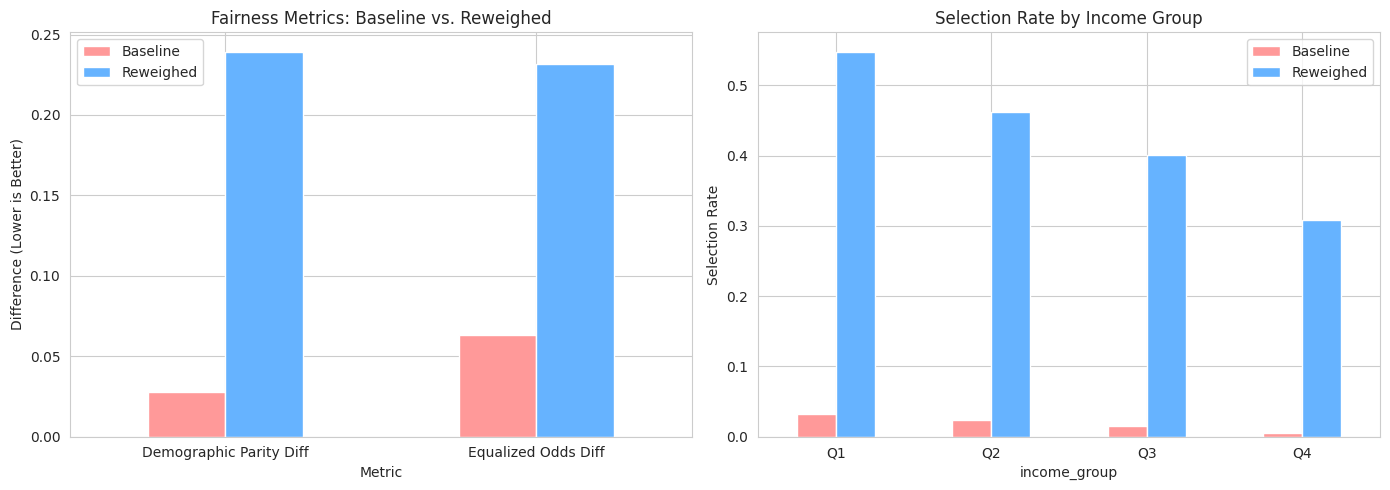

<Figure size 1000x600 with 0 Axes>

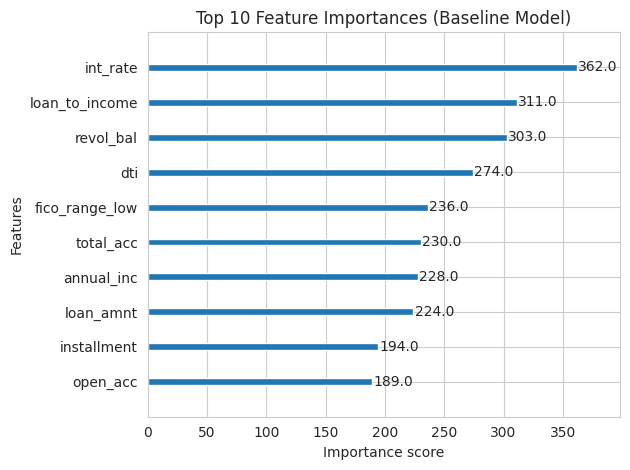

In [ ]:
# Comparison and Visuals
comparison = pd.DataFrame({
    'Metric': ['Demographic Parity Diff', 'Equalized Odds Diff'],
    'Baseline': [dp_diff, eo_diff],
    'Reweighed': [dp_diff_rw, eo_diff_rw]
})
print(comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison.set_index('Metric').plot(kind='bar', ax=axes[0], color=['#ff9999', '#66b3ff'])
axes[0].set_title('Fairness Metrics: Baseline vs. Reweighed')
axes[0].set_ylabel('Difference (Lower is Better)')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].tick_params(axis='x', rotation=0)

sr_df = pd.DataFrame({
    'Baseline': mf.by_group['selection_rate'],
    'Reweighed': mf_rw.by_group['selection_rate']
})
sr_df.plot(kind='bar', ax=axes[1], color=['#ff9999', '#66b3ff'])
axes[1].set_title('Selection Rate by Income Group')
axes[1].set_ylabel('Selection Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('fairness_comparison.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
xgb.plot_importance(model, max_num_features=10, importance_type='weight')
plt.title('Top 10 Feature Importances (Baseline Model)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

In [27]:
DIABETES_PATH = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'

In [32]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv.zip', 'r') as z:
    print("Files inside:", z.namelist())
    z.extractall('/content/drive/MyDrive/')

Files inside: ['diabetes_binary_health_indicators_BRFSS2015.csv']


In [34]:
# Load Diabetes Data
DIABETES_PATH = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'

df_diab = pd.read_csv(DIABETES_PATH)
print(f"Shape: {df_diab.shape}")
print(df_diab['Diabetes_binary'].value_counts(normalize=True))

y_diab = df_diab['Diabetes_binary'].astype(int)
X_diab = df_diab.drop(columns=['Diabetes_binary'])

df_diab['age_group'] = pd.cut(
    df_diab['Age'],
    bins=[0, 4, 8, 13],
    labels=['Young', 'Middle', 'Older']
)
sens_diab = df_diab['age_group'].astype(str)

X_d_train, X_d_test, y_d_train, y_d_test, sens_d_train, sens_d_test = train_test_split(
    X_diab, y_diab, sens_diab, test_size=0.2, random_state=42, stratify=y_diab
)

print(f"Train: {X_d_train.shape}, Test: {X_d_test.shape}")
print(sens_d_train.value_counts())

Shape: (253680, 22)
Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64
Train: (202944, 21), Test: (50736, 21)
age_group
Older     97688
Middle    74761
Young     30495
Name: count, dtype: int64


Accuracy: 0.7216
ROC-AUC: 0.8271
              precision    recall  f1-score   support

           0       0.96      0.71      0.81     43667
           1       0.31      0.79      0.44      7069

    accuracy                           0.72     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.72      0.76     50736



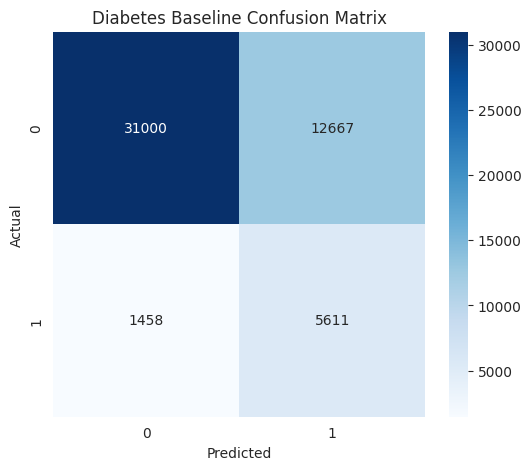

In [35]:
# Baseline XGBoost (Diabetes)
scale_d = (y_d_train == 0).sum() / (y_d_train == 1).sum()

model_d = xgb.XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_d,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
model_d.fit(X_d_train, y_d_train)

y_d_pred = model_d.predict(X_d_test)
y_d_pred_proba = model_d.predict_proba(X_d_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_d_test, y_d_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_d_test, y_d_pred_proba):.4f}")
print(classification_report(y_d_test, y_d_pred))

cm_d = confusion_matrix(y_d_test, y_d_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Blues')
plt.title('Diabetes Baseline Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('diabetes_confusion_matrix.png', dpi=300)
plt.show()

In [36]:
# Fairness Audit (Diabetes Baseline)
metrics_d = {
    'accuracy': accuracy_score,
    'selection_rate': selection_rate,
    'false_positive_rate': lambda yt, yp: confusion_matrix(yt, yp).ravel()[1] / (confusion_matrix(yt, yp).ravel()[1] + confusion_matrix(yt, yp).ravel()[0]),
    'true_positive_rate': lambda yt, yp: confusion_matrix(yt, yp).ravel()[3] / (confusion_matrix(yt, yp).ravel()[3] + confusion_matrix(yt, yp).ravel()[2])
}

mf_d = MetricFrame(metrics=metrics_d, y_true=y_d_test, y_pred=y_d_pred, sensitive_features=sens_d_test)
print(mf_d.by_group)

dp_diff_d = demographic_parity_difference(y_d_test, y_d_pred, sensitive_features=sens_d_test)
eo_diff_d = equalized_odds_difference(y_d_test, y_d_pred, sensitive_features=sens_d_test)
print(f"DP Diff: {dp_diff_d:.4f}")
print(f"EO Diff: {eo_diff_d:.4f}")

           accuracy  selection_rate  false_positive_rate  true_positive_rate
age_group                                                                   
Middle     0.782692        0.263657             0.209664            0.718317
Older      0.604808        0.531796             0.454513            0.845948
Young      0.947993        0.044006             0.032439            0.379845
DP Diff: 0.4878
EO Diff: 0.4661


In [37]:
# Reweighing Mitigation (Diabetes)
scale_d = (y_d_train == 0).sum() / (y_d_train == 1).sum()

train_d = X_d_train.copy()
train_d['target'] = y_d_train.values.astype(int)
train_d['age_group'] = sens_d_train.astype(str).values

sds_d = StandardDataset(
    train_d, label_name='target', favorable_classes=[0],
    protected_attribute_names=['age_group'],
    privileged_classes=[['Young']],
    categorical_features=[]
)

unpriv_d = [{'age_group': 'Older'}]
priv_d   = [{'age_group': 'Young'}]

rw_d = Reweighing(unprivileged_groups=unpriv_d, privileged_groups=priv_d)
rw_d.fit(sds_d)
sds_d_transf = rw_d.transform(sds_d)
weights_d = sds_d_transf.instance_weights

model_d_rw = xgb.XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_d,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
model_d_rw.fit(X_d_train, y_d_train, sample_weight=weights_d)

y_d_pred_rw = model_d_rw.predict(X_d_test)
y_d_pred_proba_rw = model_d_rw.predict_proba(X_d_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_d_test, y_d_pred_rw):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_d_test, y_d_pred_proba_rw):.4f}")
print(classification_report(y_d_test, y_d_pred_rw))

mf_d_rw = MetricFrame(metrics=metrics_d, y_true=y_d_test, y_pred=y_d_pred_rw, sensitive_features=sens_d_test)
print(mf_d_rw.by_group)

dp_diff_d_rw = demographic_parity_difference(y_d_test, y_d_pred_rw, sensitive_features=sens_d_test)
eo_diff_d_rw = equalized_odds_difference(y_d_test, y_d_pred_rw, sensitive_features=sens_d_test)
print(f"DP Diff: {dp_diff_d_rw:.4f}")
print(f"EO Diff: {eo_diff_d_rw:.4f}")

/usr/local/lib/python3.13/dist-packages/aif360/algorithms/preprocessing/reweighing.py:66: RuntimeWarning: invalid value encountered in scalar divide
  self.w_p_fav = n_fav*n_p / (n*n_p_fav)
/usr/local/lib/python3.13/dist-packages/aif360/algorithms/preprocessing/reweighing.py:67: RuntimeWarning: invalid value encountered in scalar divide
  self.w_p_unfav = n_unfav*n_p / (n*n_p_unfav)
/usr/local/lib/python3.13/dist-packages/aif360/algorithms/preprocessing/reweighing.py:68: RuntimeWarning: invalid value encountered in scalar divide
  self.w_up_fav = n_fav*n_up / (n*n_up_fav)
/usr/local/lib/python3.13/dist-packages/aif360/algorithms/preprocessing/reweighing.py:69: RuntimeWarning: invalid value encountered in scalar divide
  self.w_up_unfav = n_unfav*n_up / (n*n_up_unfav)


Accuracy: 0.7216
ROC-AUC: 0.8271
              precision    recall  f1-score   support

           0       0.96      0.71      0.81     43667
           1       0.31      0.79      0.44      7069

    accuracy                           0.72     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.72      0.76     50736

           accuracy  selection_rate  false_positive_rate  true_positive_rate
age_group                                                                   
Middle     0.782692        0.263657             0.209664            0.718317
Older      0.604808        0.531796             0.454513            0.845948
Young      0.947993        0.044006             0.032439            0.379845
DP Diff: 0.4878
EO Diff: 0.4661


           Domain     Model  DP Diff  EO Diff
    Credit (Loan)  Baseline 0.027440 0.063017
    Credit (Loan) Reweighed 0.239426 0.231688
Health (Diabetes)  Baseline 0.487790 0.466103
Health (Diabetes) Reweighed 0.487790 0.466103


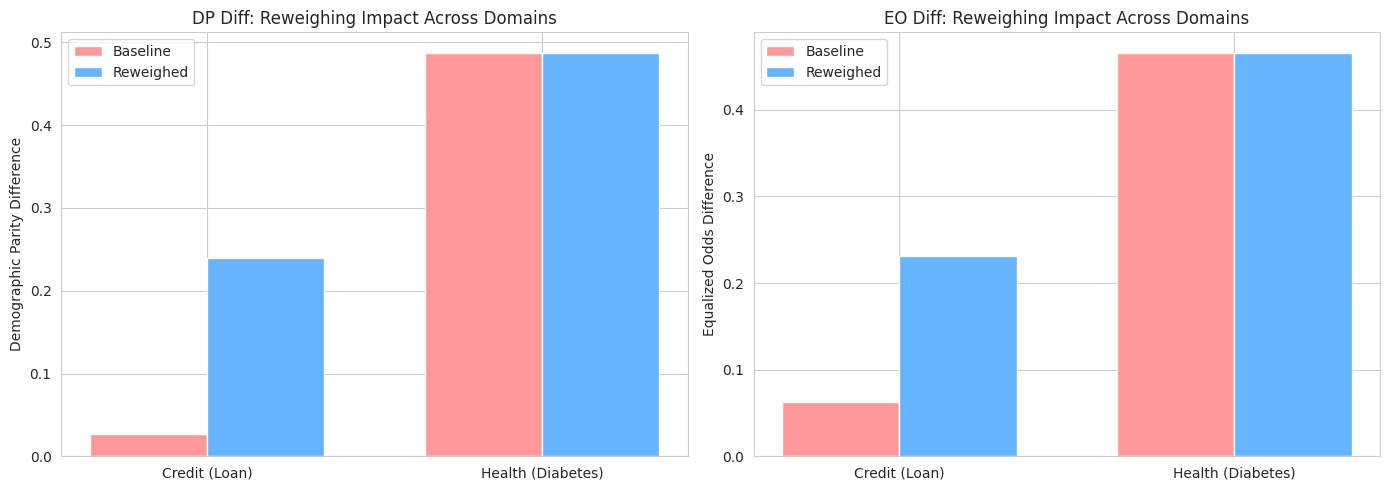

<Figure size 1000x600 with 0 Axes>

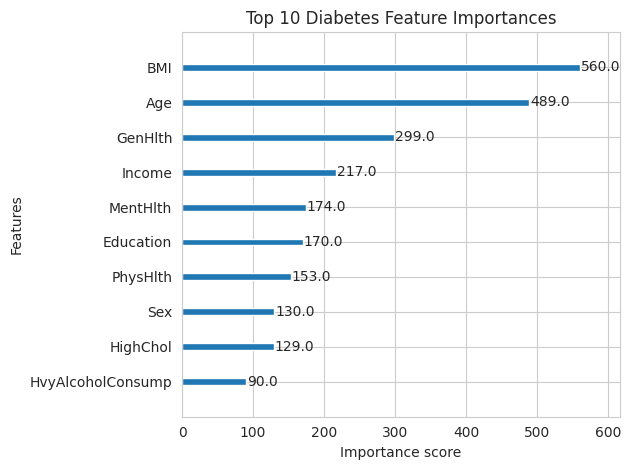

In [38]:
# Cross-Domain Comparison (Credit vs Health)
comparison_df = pd.DataFrame({
    'Domain':   ['Credit (Loan)', 'Credit (Loan)', 'Health (Diabetes)', 'Health (Diabetes)'],
    'Model':    ['Baseline', 'Reweighed', 'Baseline', 'Reweighed'],
    'DP Diff':  [dp_diff, dp_diff_rw, dp_diff_d, dp_diff_d_rw],
    'EO Diff':  [eo_diff, eo_diff_rw, eo_diff_d, eo_diff_d_rw]
})
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(2)
width = 0.35

axes[0].bar(x - width/2, [dp_diff, dp_diff_d], width, label='Baseline', color='#ff9999')
axes[0].bar(x + width/2, [dp_diff_rw, dp_diff_d_rw], width, label='Reweighed', color='#66b3ff')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Credit (Loan)', 'Health (Diabetes)'])
axes[0].set_ylabel('Demographic Parity Difference')
axes[0].set_title('DP Diff: Reweighing Impact Across Domains')
axes[0].legend()

axes[1].bar(x - width/2, [eo_diff, eo_diff_d], width, label='Baseline', color='#ff9999')
axes[1].bar(x + width/2, [eo_diff_rw, eo_diff_d_rw], width, label='Reweighed', color='#66b3ff')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Credit (Loan)', 'Health (Diabetes)'])
axes[1].set_ylabel('Equalized Odds Difference')
axes[1].set_title('EO Diff: Reweighing Impact Across Domains')
axes[1].legend()

plt.tight_layout()
plt.savefig('cross_domain_comparison.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
xgb.plot_importance(model_d, max_num_features=10, importance_type='weight')
plt.title('Top 10 Diabetes Feature Importances')
plt.tight_layout()
plt.savefig('diabetes_feature_importance.png', dpi=300)
plt.show()